# Monte Carlo Neutron Transport
### Absorption, scattering and transmission in homogeneous and layered slabs

**Author:** Ruijia Liu  
**Origin:** PHYS20762 Computational Physics  

---

## Overview

This notebook presents a Monte Carlo simulation of thermal neutron transport through finite shielding slabs. The calculation follows individual neutron histories through random free paths, absorption events, isotropic scattering events and possible escape from the slab boundaries. By repeating this process for many incident neutrons, the simulation estimates the probabilities of absorption, reflection and transmission for water, lead and graphite.

The work is treated as a computational physics report rather than only a programming exercise. Random-number generation, exponential sampling, isotropic direction sampling and neutron tallies are validated before the final material comparisons are interpreted. Statistical uncertainties are reported for Monte Carlo estimates, and attenuation lengths are extracted from thickness-dependent transmission data with appropriate fitting checks.

The model uses a simplified one-group description of thermal neutrons: cross sections are fixed for each material and neutron energy is not evolved during transport. This approximation keeps the simulation computationally efficient while preserving the main transport mechanisms required in the project brief: random interaction lengths, branching between absorption and scattering, isotropic scattering directions, and finite-geometry escape.

## Structure of this Notebook

1. **Monte Carlo Foundations**
   - 1.1 Uniform random number validation
   - 1.2 3D random points, spectral test, and comparison with a bad generator
&nbsp;
2. **Exponential Sampling and Absorption-Only Validation**
   - 2.1 Inverse-CDF sampling of exponential path lengths
   - 2.2 Absorption-only test for water
&nbsp;
3. **Isotropic Direction and Step Generation**
   - 3.1 Isotropic direction sampling and validation
   - 3.2 Isotropic exponential steps
&nbsp;
4. **Physical Model and Material Properties**
&nbsp;
5. **Single-Particle History Simulation**
&nbsp;
6. **Slab Transport Simulation and Outcome Tallies**
&nbsp;
7. **Thickness Dependence and Attenuation Lengths**
   - 7.1 Absorption, reflection and transmission versus thickness
   - 7.2 Determination of attenuation length
&nbsp;
8. **Extension: Woodcock Method for Two-Layer Slabs**
   - 8.1 Woodcock method and majorant cross section
   - 8.2 Woodcock two-slab validation and material comparison
   - 8.3 Exploratory extension: machine-learning surrogate model for shielding design
&nbsp;
9. **Conclusion**

---
# Core imports and global settings

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from typing import Optional
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

SEED = 20260915
np.random.seed(SEED)

# Start timing the notebook so that the total runtime can be checked at the end.
notebook_start_time = time.perf_counter()

# Set default plotting options used throughout the notebook.
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "font.size": 11,
})

---
# 1. Monte Carlo Foundations
The one-dimensional statistical test and the three-dimensional spectral test show that `numpy.random.uniform()` produces random numbers that are both statistically consistent with a uniform distribution and visually free from obvious correlations, making it suitable for the Monte Carlo sampling used in the rest of the simulation.

## 1.1 Uniform random number validation

To check the built-in random number generator, samples were drawn from the uniform distribution

$$
u \sim U(0,1).
$$

For this distribution, the expected mean and variance are

$$
\langle u \rangle = 0.5, \qquad \mathrm{Var}(u) = \frac{1}{12} \approx 0.08333.
$$

Several sample sizes were tested, from $N=10$ to $N=100000$. The table shows that, as $N$ increases, the sample mean and variance approach their expected values.

The histograms provide a visual check of uniformity. With $n_\mathrm{bins}=20$, the expected count in each bin is

$$
\mu = \frac{N}{n_\mathrm{bins}},
$$

with binomial fluctuation

$$
\sigma = \sqrt{Np(1-p)}, \qquad p=\frac{1}{n_\mathrm{bins}}.
$$

For small $N$, the bin heights fluctuate strongly. For larger $N$, they become more even and stay close to the expected count line. These limited diagnostics support using `numpy.random.uniform()` for the later Monte Carlo simulation.

In [2]:
sample_sizes = [10,100, 1000, 10000,100000] # Use several sample sizes to check convergence of the random-number statistics.
n_bins = 20

In [3]:
uniform_samples = {
    N: np.random.uniform(0.0, 1.0, size=N) # Generate independent samples from U(0, 1) for each chosen sample size.
    for N in sample_sizes
}

# Compare measured statistics with the theoretical values:
uniform_stats_by_N = pd.DataFrame([
    {
        "N": N,
        "sample mean": np.mean(u),
        "expected mean": 0.5,
        "mean error": np.mean(u) - 0.5,
        "sample variance": np.var(u, ddof=1),
        "expected variance": 1 / 12,
        "variance error": np.var(u, ddof=1) - 1 / 12,
        "minimum": np.min(u),
        "maximum": np.max(u),
    }
    for N, u in uniform_samples.items()
])

uniform_stats_by_N.style.format({
    col: "{:.5f}" for col in uniform_stats_by_N.columns if col != "N"
})

,N,sample mean,expected mean,mean error,sample variance,expected variance,variance error,minimum,maximum
0,10,0.64556,0.50000,0.14556,0.02360,0.08333,-0.05973,0.34574,0.82700
1,100,0.49381,0.50000,-0.00619,0.08111,0.08333,-0.00223,0.00034,0.99488
2,1000,0.51301,0.50000,0.01301,0.08677,0.08333,0.00344,0.00069,0.99963
3,10000,0.50208,0.50000,0.00208,0.08390,0.08333,0.00056,0.00001,0.99984
4,100000,0.50080,0.50000,0.00080,0.08352,0.08333,0.00018,0.00001,1.00000


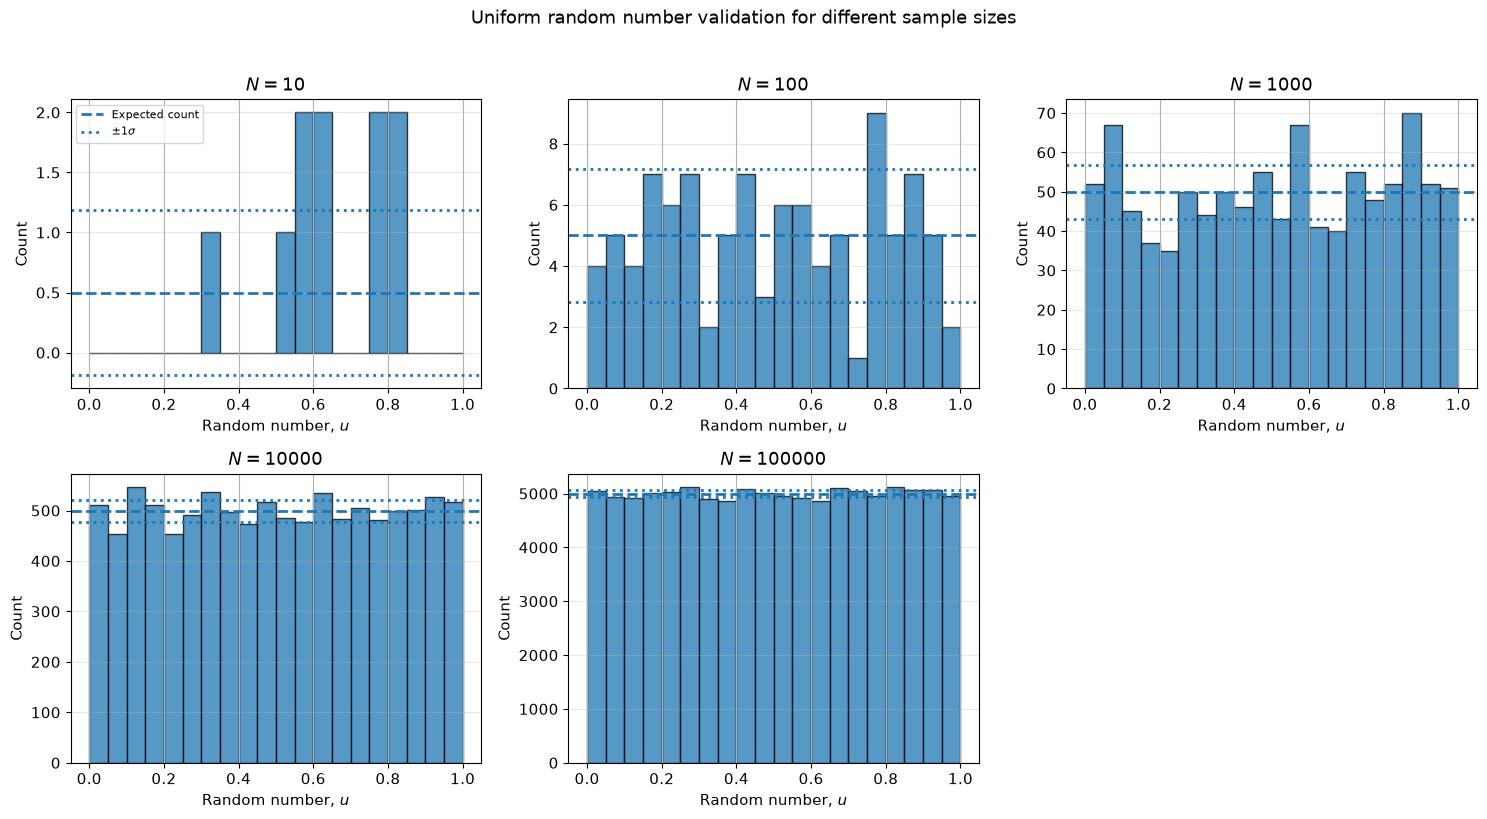

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, N in zip(axes, sample_sizes):
    counts, edges = np.histogram(uniform_samples[N], bins=n_bins, range=(0, 1))
    centres = 0.5 * (edges[:-1] + edges[1:])
    # For a uniform distribution, each bin has probability p = 1 / n_bins.
    # Therefore the expected bin count is Np, with binomial standard deviation.
    p_bin = 1 / n_bins
    expected = N * p_bin
    sigma = np.sqrt(N * p_bin * (1 - p_bin))

    ax.bar(centres, counts, width=edges[1]-edges[0], alpha=0.75, edgecolor="black")
    ax.axhline(expected, ls="--", lw=2, label="Expected count")
    ax.axhline(expected + sigma, ls=":", lw=2, label=r"$\pm 1\sigma$")
    ax.axhline(expected - sigma, ls=":", lw=2)
    ax.set(title=rf"$N={N}$", xlabel=r"Random number, $u$", ylabel="Count")
    ax.grid(axis="y", alpha=0.3)

axes[-1].axis("off")# The 2 x 3 grid has six panels, but only five sample sizes are plotted.
axes[0].legend(fontsize=8)
fig.suptitle("Uniform random number validation for different sample sizes", y=1.02)
plt.tight_layout()
plt.show()

## 1.2 Three-dimensional spectral test

This section provides a visual check that random numbers generated by `numpy.random.uniform()` do not show spectral issues when grouped into three-dimensional points. Therefore, random numbers were generated in triples and plotted as points in the unit cube:

$$
(x_i, y_i, z_i) \in [0,1]^3.
$$

A good random number generator should fill the cube without visible planes, bands, or clustering. For comparison, a `randssp` linear congruential generator was also tested. This generator uses the recurrence

$$
X_{n+1} = (aX_n + c)\ \mathrm{mod}\ m,
$$

and is deliberately poor, so it is expected to show correlations in three dimensions.

The NumPy-generated points fill the cube evenly, with no obvious planar structure. In contrast, the `randssp` points show visible alignment, demonstrating the spectral problem. These limited diagnostics support using `numpy.random.uniform()` for the later Monte Carlo transport simulation, where random numbers are used to sample particle positions, directions and interaction events.

In [5]:
N_3d = 5000

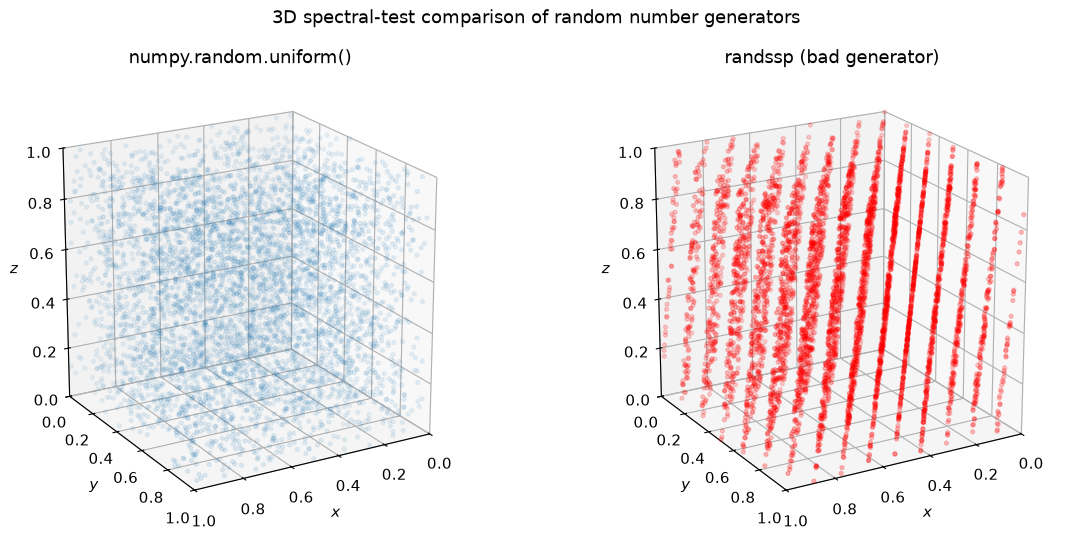

In [6]:
# Generate 3D points using NumPy's built-in uniform random generator.
points_3d = np.random.uniform(0.0, 1.0, size=(N_3d, 3))

# RANDU-style bad generator used to demonstrate spectral correlations.
m, a, c, x = 2**31, 2**16 + 3, 0, 123456789

def randssp(p, q):
    global x
    r = np.zeros((p, q))
    for j in range(q):
        for i in range(p):
            x = (a * x + c) % m
            r[i, j] = x / m
    return r

# Transpose so each row is one point: (x, y, z).
bad_points_3d = randssp(3, N_3d).T

# Compare the 3D point distributions visually.
fig = plt.figure(figsize=(12, 5.5))

for i, (points, title, color, alpha) in enumerate([
    (points_3d, "numpy.random.uniform()", None, 0.35),
    (bad_points_3d, "randssp (bad generator)", "r", 0.55)
], start=1):
    ax = fig.add_subplot(1, 2, i, projection="3d")
    ax.scatter(points[:, 0], points[:, 1], points[:, 2],
               s=8, alpha=alpha, color=color)

    ax.set(title=title, xlabel="$x$", ylabel="$y$", zlabel="$z$",
           xlim=(0, 1), ylim=(0, 1), zlim=(0, 1))
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=20, azim=60)

fig.suptitle("3D spectral-test comparison of random number generators", fontsize=13)
plt.tight_layout()
plt.show()

---
# 2. Exponential Sampling and Absorption-Only Validation

This section validates the exponential inverse-CDF sampler and shows that, in the absorption-only limit, the simulated attenuation in water recovers the expected mean free path from the macroscopic absorption cross-section.

## 2.1 Inverse-CDF sampling of exponential path lengths

Neutron flight distances between interactions are sampled from an exponential distribution. For a mean free path $\lambda$, the probability density is

$$
p(s)=\frac{1}{\lambda}\exp\left(-\frac{s}{\lambda}\right),
$$

where $s$ is the sampled path length. Using inverse-CDF sampling, a uniformly distributed random number $u\in(0,1)$ is transformed into an exponential path length by

$$
s=-\lambda \ln u.
$$

The function below implements this transformation and is tested by comparing the sampled distribution with the theoretical exponential probability density. The sample mean should approach the input mean free path as the number of samples becomes large.

In [7]:
def sample_exponential_steps(lam, size):
    """
    Generate exponentially distributed path lengths with mean free path lam.

    Parameters
    ----------
    lam : float
        Mean free path in cm.
    size : int or tuple
        Number or shape of samples to generate.

    Returns
    -------
    steps : ndarray
        Random path lengths sampled from p(s) = exp(-s/lam) / lam.
    """
    u = np.random.uniform(0.0, 1.0, size=size)

    # Avoid log(0), which would produce an infinite path length.
    u = np.clip(u, np.finfo(float).tiny, 1.0)

    return -lam * np.log(u)

In [8]:
lambda_test, N_test = 10.0, 100000# Validate that inverse-CDF sampling produces exponential step lengths with mean close to lambda_test.

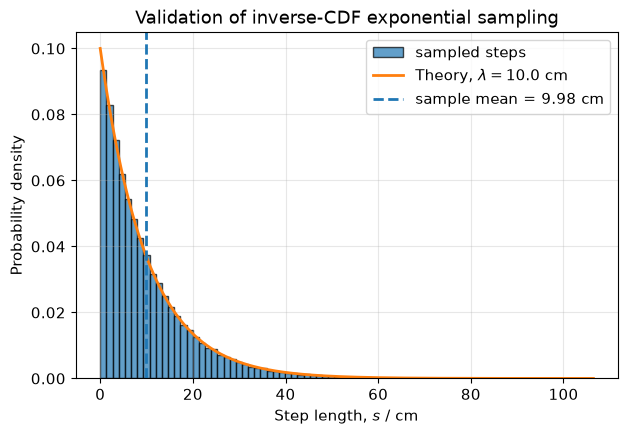

Input lambda: 10.000 cm
Sample mean:  9.980 cm


In [9]:
steps_test = sample_exponential_steps(lambda_test, N_test)#It uses a generic function starting with 2.1: sample_exponential_steps
mean_step = np.mean(steps_test)
s_plot = np.linspace(0, steps_test.max(), 500)

fig, ax = plt.subplots()
ax.hist(steps_test, bins=80, density=True, alpha=0.70,
        edgecolor="black", label="sampled steps")
ax.plot(s_plot, np.exp(-s_plot / lambda_test) / lambda_test, lw=2,
        label=fr"Theory, $\lambda={lambda_test:.1f}\ \mathrm{{cm}}$")
ax.axvline(mean_step, ls="--", lw=2,
           label=f"sample mean = {mean_step:.2f} cm")

ax.set(xlabel=r"Step length, $s$ / cm",
       ylabel="Probability density",
       title="Validation of inverse-CDF exponential sampling")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Input lambda: {lambda_test:.3f} cm")
print(f"Sample mean:  {mean_step:.3f} cm")

## 2.2 Absorption-only test for water

As a validation case, scattering is temporarily ignored so that neutron loss in water is controlled only by absorption. The microscopic absorption cross-section is converted into a macroscopic absorption cross-section using

$$
\Sigma_a = n\sigma_a,
$$

where $n$ is the molecular number density and $\sigma_a$ is the microscopic absorption cross-section. The absorption mean free path is therefore

$$
\lambda_a=\frac{1}{\Sigma_a}.
$$

Absorption depths are sampled using the exponential path-length generator. The resulting histogram should follow

$$
N(x)\propto \exp\left(-\frac{x}{\lambda_a}\right).
$$

Taking the logarithm gives a straight-line relation,

$$
\ln N(x)=C-\frac{x}{\lambda_a},
$$

so a weighted linear fit to the binned data can be used to recover the attenuation length. Empty bins are removed before fitting to avoid taking the logarithm of zero.

In [10]:
N_A = 6.02214076e23  # mol^-1
BARN_TO_CM2 = 1e-24   # cm^2

water = {
    "material": "Water",
    "sigma_a_barn": 0.6652,
    "sigma_s_barn": 103.0,
    "density_g_cm3": 1.00,
    "molar_mass_g_mol": 18.0153,
}

n_water = water["density_g_cm3"] * N_A / water["molar_mass_g_mol"]
Sigma_a_water = n_water * water["sigma_a_barn"] * BARN_TO_CM2
lambda_a_water = 1 / Sigma_a_water

water_absorption_properties = pd.DataFrame({
    "quantity": [
        "number density",
        "microscopic absorption cross-section",
        "macroscopic absorption cross-section",
        "absorption mean free path",
    ],
    "value": [n_water, water["sigma_a_barn"], Sigma_a_water, lambda_a_water],
    "unit": [r"cm$^{-3}$", "barn", r"cm$^{-1}$", "cm"],
})

water_absorption_properties

,quantity,value,unit
0,number density,3.342792e+22,cm$^{-3}$
1,microscopic absorption cross-section,6.652000e-01,barn
2,macroscopic absorption cross-section,2.223625e-02,cm$^{-1}$
3,absorption mean free path,4.497160e+01,cm


In [11]:
num_particles = 10000  # Number of neutrons sampled in each absorption-only simulation.
num_bins = 30          # Number of histogram bins used to group absorption depths.
num_iter = 10          # Number of repeated simulations used to estimate statistical fluctuations.

In [12]:
# Use a wide range so that the exponential tail is included.
r_max = 10.0 * lambda_a_water
hist_range = (0.0, r_max)

frequency=np.zeros((num_iter,num_bins))

for i in range(num_iter):
    depths_i = sample_exponential_steps(lambda_a_water, num_particles)#It uses a generic function starting with 2.1: sample_exponential_steps

    frequency[i,:], bin_edges = np.histogram(depths_i, bins=num_bins, range=hist_range)

# Convert histogram edges to bin centres.
# The fitted x-value should represent the middle of each histogram bin,
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

mean_counts = np.mean(frequency, axis=0)
std_counts = np.std(frequency, axis=0, ddof=1)

# Remove empty bins before taking the logarithm.
nonzero_mask = (mean_counts > 0) & (std_counts > 0)

x_fit = bin_centres[nonzero_mask]
mean_counts_fit = mean_counts[nonzero_mask]
std_counts_fit = std_counts[nonzero_mask]

# Use the standard deviation between repeated histograms as a conservative uncertainty.
error = std_counts_fit / mean_counts_fit

coefficient, covariance = np.polyfit(x_fit, np.log(mean_counts_fit), 1, cov=True, w=1 / error)

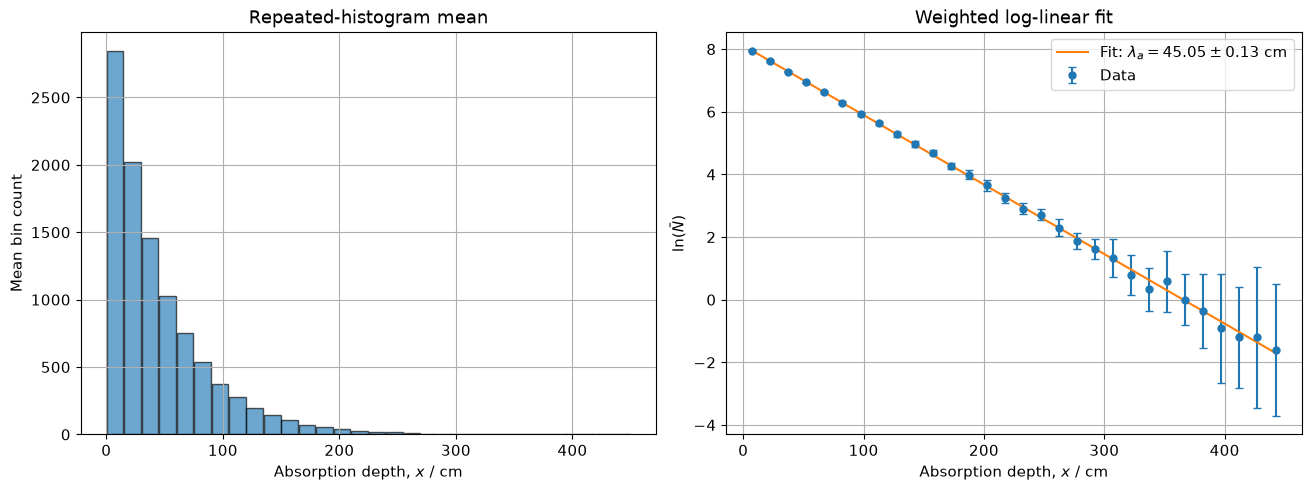

Theoretical lambda_a = 44.97 cm
Fitted lambda_a      = 45.05 ± 0.13 cm


In [13]:
slope, intercept = coefficient
lambda_fit_water = -1 / slope
lambda_unc_water = np.sqrt(covariance[0, 0]) / slope**2
x_line = np.linspace(x_fit.min(), x_fit.max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].bar(x_fit, mean_counts_fit, width=0.95 * bin_width,
            alpha=0.65, edgecolor="black")
axes[0].set(xlabel="Absorption depth, $x$ / cm",
            ylabel="Mean bin count",
            title="Repeated-histogram mean")

axes[1].errorbar(x_fit, np.log(mean_counts_fit), yerr=error,
                 fmt="o", markersize=5, capsize=3, label="Data")
axes[1].plot(x_line, intercept + slope * x_line,
             label=rf"Fit: $\lambda_a={lambda_fit_water:.2f}\pm{lambda_unc_water:.2f}$ cm")
axes[1].set(xlabel="Absorption depth, $x$ / cm",
            ylabel=r"$\ln(\bar{N})$",
            title="Weighted log-linear fit")
axes[1].legend()

plt.show()

print(f"Theoretical lambda_a = {lambda_a_water:.2f} cm")
print(f"Fitted lambda_a      = {lambda_fit_water:.2f} ± {lambda_unc_water:.2f} cm")

---
# 3. Isotropic Direction and Step Generation
This section validates the random step generator used later in the neutron transport simulation: the scattering directions are isotropic, and the step lengths follow the required exponential mean-free-path distribution.

## 3.1 Isotropic direction sampling and validation

For isotropic scattering, the direction after a scattering event must be uniformly distributed over the surface of a sphere, not uniformly distributed in the polar angle $\theta$. The correct sampling uses

$$
\phi \sim U(0, 2\pi),
$$

and

$$
z = \cos\theta \sim U(-1, 1).
$$

The corresponding unit vector is

$$
\vec r =
\left(
\sqrt{1-z^2}\cos\phi,\,
\sqrt{1-z^2}\sin\phi,\,
z
\right).
$$

A comparison was made with the incorrect method $\theta \sim U(0,\pi)$. The incorrect method produces excess points near the poles, visible both in the 3D sphere plot and in the non-uniform $z=\cos\theta$ histogram. In contrast, the correct method gives a flat $z$ distribution with density $1/2$ over $[-1,1]$, as expected for isotropic scattering.

The generated vectors were also checked numerically by calculating their lengths. The mean vector length is approximately one, confirming that the function produces unit vectors suitable for later neutron random-walk simulations.

In [14]:
def sample_isotropic_unit_vectors(size=None):
    """
    Generate isotropic unit vector(s) in 3D.

    The azimuthal angle phi is sampled uniformly in [0, 2pi),
    while z = cos(theta) is sampled uniformly in [-1, 1].
    """
    if size is None:
        phi = 2.0 * np.pi * np.random.uniform(0.0, 1.0)
        z = 1.0 - 2.0 * np.random.uniform(0.0, 1.0)
        r_xy = np.sqrt(max(0.0, 1.0 - z**2))

        return r_xy * np.cos(phi), r_xy * np.sin(phi), z

    phi = 2.0 * np.pi * np.random.uniform(0.0, 1.0, size=size)
    z = 1.0 - 2.0 * np.random.uniform(0.0, 1.0, size=size)
    r_xy = np.sqrt(np.maximum(0.0, 1.0 - z**2))

    return np.column_stack((r_xy * np.cos(phi), r_xy * np.sin(phi), z))


def sample_isotropic_mu(size=None):
    """
    Sample the x-component of an isotropic unit vector.

    This is useful when only the x-displacement is needed:
    dx = step_length * mu.
    """
    return 1.0 - 2.0 * np.random.uniform(0.0, 1.0, size=size)

In [15]:
# Number of directions used for numerical validation
N_dir_test = 10000
# Number of points shown in the 3D scatter plots
sample_for_plot = 3000
# Number of bins used in the z-distribution histograms
num_z_bins = 50

Mean vector length: 1.000000
Maximum absolute deviation from 1: 2.220e-16


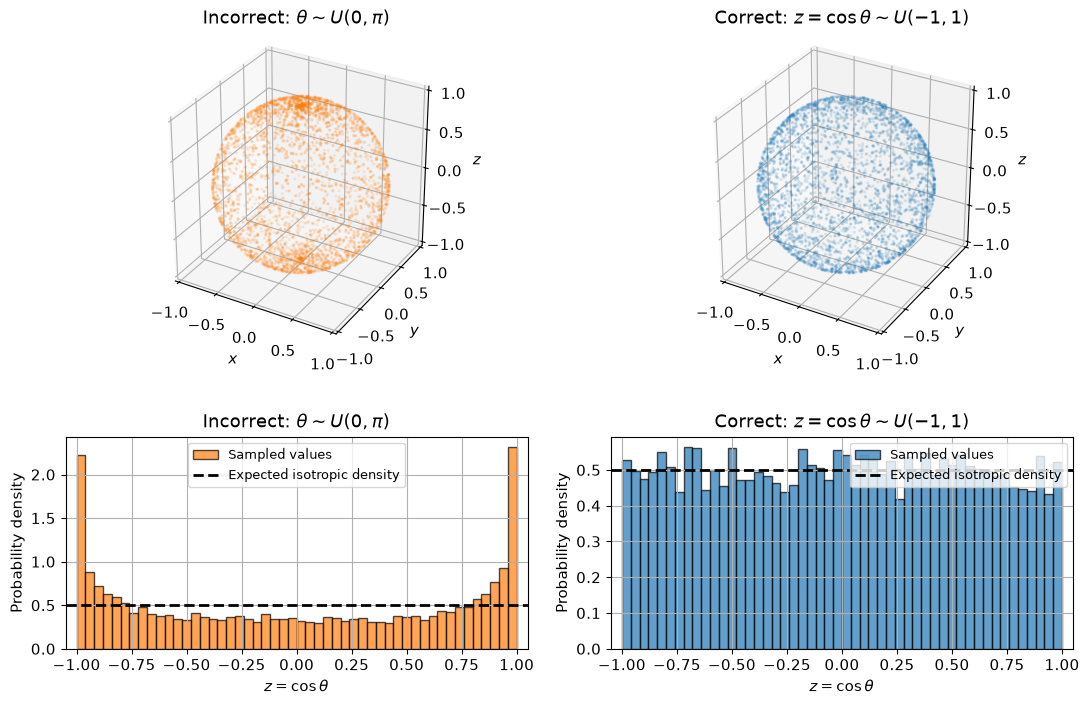

,method,mean of z,variance of z,minimum z,maximum z,expected mean,expected variance
0,incorrect uniform theta,0.002974,0.496129,-1.000000,1.000000,0.0,0.333333
1,correct isotropic sampling,-0.003724,0.330382,-0.999972,0.999957,0.0,0.333333


In [16]:
# Compare incorrect uniform-theta sampling with correct isotropic sampling

# Incorrect method: theta is sampled uniformly, causing pole clustering.
theta_wrong = np.random.uniform(0.0, np.pi, N_dir_test)
phi_wrong = np.random.uniform(0.0, 2.0 * np.pi, N_dir_test)

wrong_directions = np.column_stack((
    np.sin(theta_wrong) * np.cos(phi_wrong),
    np.sin(theta_wrong) * np.sin(phi_wrong),
    np.cos(theta_wrong)
))

# Correct method: z = cos(theta) is sampled uniformly in [-1, 1].
directions = sample_isotropic_unit_vectors(N_dir_test)#This uses functions starting with 3.1: sample_isotropic_unit_vectors

z_wrong = wrong_directions[:, 2]
z_correct = directions[:, 2]
lengths = np.linalg.norm(directions, axis=1)

print(f"Mean vector length: {np.mean(lengths):.6f}")
print(f"Maximum absolute deviation from 1: {np.max(np.abs(lengths - 1)):.3e}")

# Top row: 3D sphere comparison; bottom row: z-distribution comparison.
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 0.85], hspace=0.35, wspace=0.18)

plot_data = [
    (wrong_directions, z_wrong, r"Incorrect: $\theta \sim U(0,\pi)$", "tab:orange"),
    (directions, z_correct, r"Correct: $z=\cos\theta \sim U(-1,1)$", "tab:blue")
]

for i, (points, z_data, title, color) in enumerate(plot_data):
    ax = fig.add_subplot(gs[0, i], projection="3d")
    ax.scatter(points[:sample_for_plot, 0],
               points[:sample_for_plot, 1],
               points[:sample_for_plot, 2],
               s=2, alpha=0.45, color=color)
    ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$",
           title=title, xlim=(-1.05, 1.05),
           ylim=(-1.05, 1.05), zlim=(-1.05, 1.05))
    ax.set_box_aspect((1, 1, 1))

    ax = fig.add_subplot(gs[1, i])
    ax.hist(z_data, bins=num_z_bins, range=(-1, 1), density=True,
            alpha=0.70, edgecolor="black", color=color,
            label="Sampled values")
    ax.axhline(0.5, linestyle="--", linewidth=2,
               color="black", label="Expected isotropic density")
    ax.set(xlabel=r"$z=\cos\theta$", ylabel="Probability density",
           title=title, xlim=(-1.05, 1.05))
    ax.legend(fontsize=9)

plt.show()

z_validation = pd.DataFrame({
    "method": ["incorrect uniform theta", "correct isotropic sampling"],
    "mean of z": [np.mean(z_wrong), np.mean(z_correct)],
    "variance of z": [np.var(z_wrong, ddof=1), np.var(z_correct, ddof=1)],
    "minimum z": [np.min(z_wrong), np.min(z_correct)],
    "maximum z": [np.max(z_wrong), np.max(z_correct)],
    "expected mean": [0.0, 0.0],
    "expected variance": [1.0 / 3.0, 1.0 / 3.0]
})

z_validation

## 3.2 Isotropic exponential steps

After validating the isotropic direction generator, each neutron step was constructed by combining an exponentially distributed step length with an isotropic unit vector. The step length is sampled from

$$
p(s)=\frac{1}{\lambda}\exp\left(-\frac{s}{\lambda}\right),
$$

where $\lambda$ is the mean free path. The full three-dimensional step vector is then

$$
\Delta \vec r = s\hat r,
$$

where $\hat r$ is an isotropically sampled unit vector.

This means the magnitude of each step follows the required exponential distribution, while the direction has no preferred orientation. The sampled mean step length was compared with the input mean free path, and the mean values of the $x$, $y$, and $z$ step components were checked to be close to zero, as expected for isotropic motion. The histogram of $|\Delta \vec r|$ agrees with the theoretical exponential probability density, confirming that the generated steps are suitable for the later neutron random-walk simulation.

In [17]:
# Mean free path used for the example validation
lambda_example = 10.0  # cm
# Number of isotropic exponential steps generated
N_steps_example = 5000

In [18]:
def sample_isotropic_steps(mean_free_path: float, size: int) -> np.ndarray:
    
    step_lengths = sample_exponential_steps(mean_free_path, size)#It uses a generic function starting with 2.1: sample_exponential_steps
    unit_vectors = sample_isotropic_unit_vectors(size)#This uses functions starting with 3.1: sample_isotropic_unit_vectors

    return step_lengths[:, None] * unit_vectors

example_steps = sample_isotropic_steps(mean_free_path=lambda_example, size=N_steps_example)
example_step_lengths = np.linalg.norm(example_steps, axis=1)
mean_components = np.mean(example_steps, axis=0)

print(f"Input mean free path: {lambda_example:.3f} cm")
print(f"Mean sampled step length: {np.mean(example_step_lengths):.3f} cm")
print(f"Mean step components: "
      f"({mean_components[0]:.3e}, "
      f"{mean_components[1]:.3e}, "
      f"{mean_components[2]:.3e}) cm")

Input mean free path: 10.000 cm
Mean sampled step length: 10.093 cm
Mean step components: (-1.515e-02, 6.996e-02, 2.431e-02) cm


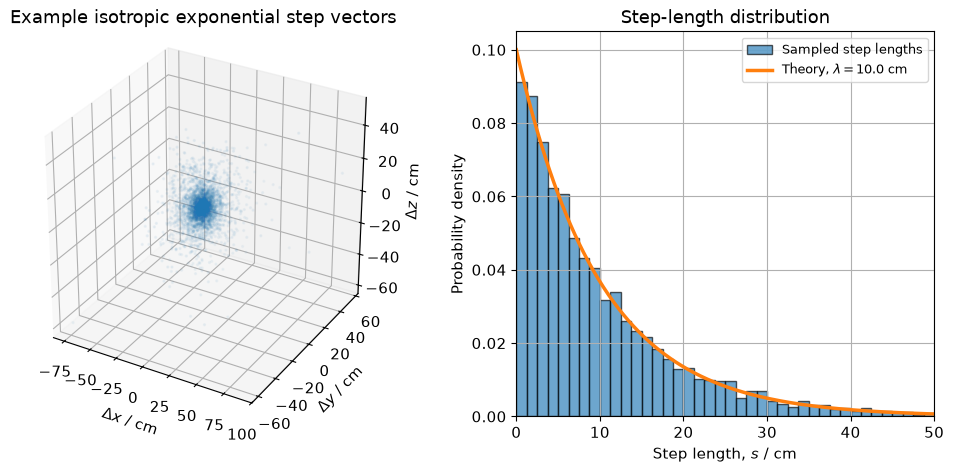

In [19]:
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.05], wspace=0.28)
ax1 = fig.add_subplot(gs[0, 0], projection="3d")

ax1.scatter(example_steps[:, 0], example_steps[:, 1], example_steps[:, 2],
            s=2, alpha=0.25)

ax1.set(xlabel=r"$\Delta x$ / cm",
        ylabel=r"$\Delta y$ / cm",
        zlabel=r"$\Delta z$ / cm",
        title="Example isotropic exponential step vectors")

ax1.set_box_aspect((1, 1, 1))

s_plot = np.linspace(0.0, 5.0 * lambda_example, 500)
pdf_example = (1.0 / lambda_example) * np.exp(-s_plot / lambda_example)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(example_step_lengths,
         bins=40,
         range=(0.0, 5.0 * lambda_example),
         density=True,
         alpha=0.65,
         edgecolor="black",
         label="Sampled step lengths")

ax2.plot(s_plot, pdf_example,
         linewidth=2.5,
         label=fr"Theory, $\lambda = {lambda_example:.1f}$ cm")

ax2.set(xlabel=r"Step length, $s$ / cm",
        ylabel="Probability density",
        title="Step-length distribution",
        xlim=(0.0, 5.0 * lambda_example))

ax2.legend(fontsize=9)

plt.show()

# 4. Physical Model and Material Properties

Before simulating neutron histories, the microscopic cross-section data must be converted into macroscopic material properties. The project uses c.g.s. units, so microscopic cross sections are converted from barns to $\mathrm{cm^2}$, while macroscopic cross sections are expressed in $\mathrm{cm^{-1}}$.

For a material with density $\rho$ and molar mass $M$, the number density is

$$
n = \frac{\rho N_A}{M},
$$

where $N_A$ is Avogadro's constant. The macroscopic absorption and scattering cross sections are then

$$
\Sigma_a = n\sigma_a,
\qquad
\Sigma_s = n\sigma_s.
$$

The total macroscopic cross section is

$$
\Sigma_T = \Sigma_a + \Sigma_s,
$$

so the total mean free path used to sample the distance to the next interaction is

$$
\lambda_T = \frac{1}{\Sigma_T}.
$$

After an interaction occurs, the type of event is selected using the branching ratios

$$
P_a = \frac{\Sigma_a}{\Sigma_T},
\qquad
P_s = \frac{\Sigma_s}{\Sigma_T}.
$$

Therefore, $\lambda_T$ controls how far the neutron travels between interactions, while $P_a$ and $P_s$ determine whether the interaction is absorption or scattering. These material-dependent quantities are calculated once here and then reused throughout the neutron transport simulation.

In [20]:
materials = {
    "Water":    [0.6652, 103.0,   1.00,  18.0153],
    "Lead":     [0.158,  11.221, 11.35, 207.2],
    "Graphite": [0.0045, 4.74,   1.67,  12.011],
}

cols = ["sigma_a / barn", "sigma_s / barn", "density / g cm^-3", "molar mass / g mol^-1"]
material_properties = pd.DataFrame.from_dict(materials, orient="index", columns=cols)

material_properties["n / cm^-3"] = (material_properties["density / g cm^-3"] * N_A / material_properties["molar mass / g mol^-1"])
material_properties["Sigma_a / cm^-1"] = (material_properties["n / cm^-3"] * material_properties["sigma_a / barn"] * BARN_TO_CM2)
material_properties["Sigma_s / cm^-1"] = (material_properties["n / cm^-3"] * material_properties["sigma_s / barn"] * BARN_TO_CM2)
material_properties["Sigma_T / cm^-1"] = (material_properties["Sigma_a / cm^-1"] + material_properties["Sigma_s / cm^-1"])
material_properties["lambda_T / cm"] = 1 / material_properties["Sigma_T / cm^-1"]

material_properties["P_a"] = material_properties["Sigma_a / cm^-1"] / material_properties["Sigma_T / cm^-1"]
material_properties["P_s"] = material_properties["Sigma_s / cm^-1"] / material_properties["Sigma_T / cm^-1"]

summary_cols = [
    "n / cm^-3", "Sigma_a / cm^-1", "Sigma_s / cm^-1",
    "Sigma_T / cm^-1", "lambda_T / cm", "P_a", "P_s"
]

material_properties[summary_cols].style.format({
    "n / cm^-3": "{:.3e}",
    "Sigma_a / cm^-1": "{:.4e}",
    "Sigma_s / cm^-1": "{:.4e}",
    "Sigma_T / cm^-1": "{:.4e}",
    "lambda_T / cm": "{:.4f}",
    "P_a": "{:.5f}",
    "P_s": "{:.5f}",
})

,n / cm^-3,Sigma_a / cm^-1,Sigma_s / cm^-1,Sigma_T / cm^-1,lambda_T / cm,P_a,P_s
Water,3.343e+22,2.2236e-02,3.4431e+00,3.4653e+00,0.2886,0.00642,0.99358
Lead,3.299e+22,5.2121e-03,3.7016e-01,3.7537e-01,2.6640,0.01389,0.98611
Graphite,8.373e+22,3.7679e-04,3.9689e-01,3.9726e-01,2.5172,0.00095,0.99905


In [21]:
material_fast = material_properties.rename(columns={
    "Sigma_a / cm^-1": "Sigma_a",
    "Sigma_s / cm^-1": "Sigma_s",
    "Sigma_T / cm^-1": "Sigma_T",
})[["Sigma_a", "Sigma_s", "Sigma_T"]].to_dict("index")

def get_fast_material_data(material_name):
    """
    Extract macroscopic cross sections from precomputed material data.
    """
    props = material_fast[material_name]

    Sigma_a = props["Sigma_a"]
    Sigma_s = props["Sigma_s"]
    Sigma_T = props["Sigma_T"]

    return Sigma_a, Sigma_s, Sigma_T

---
# 5. Single-Particle History Simulation

This section visualises representative neutron histories in a finite slab of thickness $L$. The slab is placed between $x=0$ and $x=L$, and each neutron enters normally from the left surface, so the first step is fixed in the $+x$ direction.

Each path length is sampled from the exponential free-path distribution,

$$
s = -\lambda_T \ln(u),
$$

where $u$ is a uniform random number and $\lambda_T = 1/\Sigma_T$ is the total mean free path. After each move, the neutron position is checked. If $x<0$, the neutron is counted as reflected; if $x>L$, it is counted as transmitted.

If the neutron remains inside the slab, a second random number decides whether the interaction is absorption or scattering. The absorption probability is

$$
P_a = \frac{\Sigma_a}{\Sigma_a+\Sigma_s}.
$$

If the neutron is not absorbed, it scatters and a new isotropic direction is generated for the next step. The plots below provide a visual check that the finite-slab random-walk logic behaves as expected before running the many-particle tally simulation.

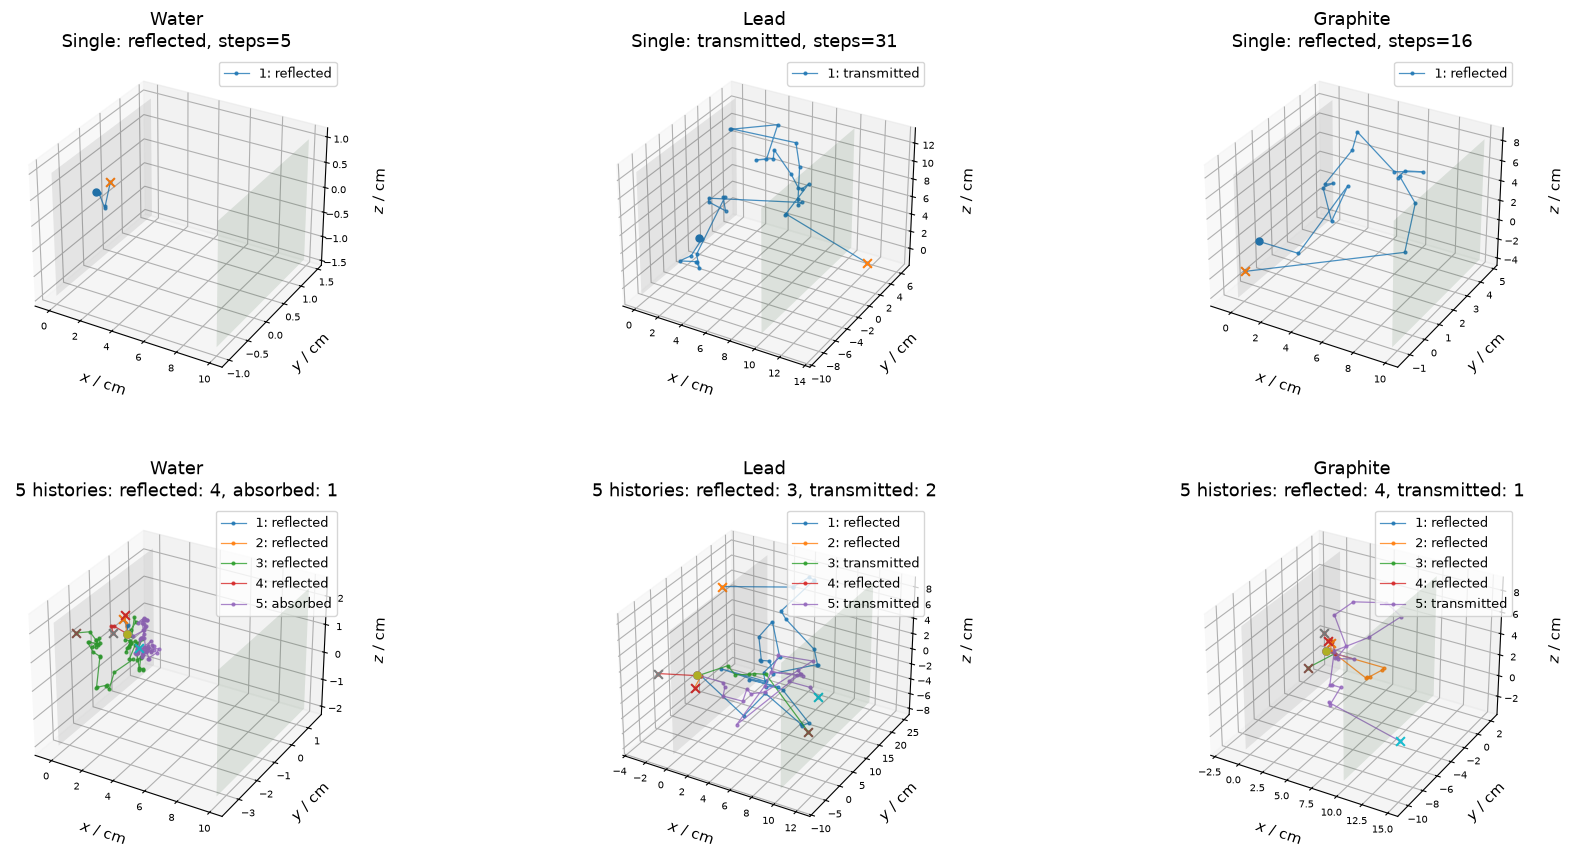

In [22]:
materials = ["Water", "Lead", "Graphite"]
L = 10.0
fig = plt.figure(figsize=(18, 8.5))

for i, mat in enumerate(materials, 1):
    Sigma_a, Sigma_s, Sigma_T = get_fast_material_data(mat)#This uses functions starting with 4: get_fast_material_data
    lam, P_a = 1 / Sigma_T, Sigma_a / Sigma_T

    def run_history(n):
        histories = []

        for _ in range(n):
            pos = [[0.0, 0.0, 0.0]]
            pos.append([sample_exponential_steps(lam, 1)[0], 0.0, 0.0])#This uses functions starting with 2.1

            outcome = None
            while outcome is None:
                x = pos[-1][0]

                if x < 0:
                    outcome = "reflected"
                elif x > L:
                    outcome = "transmitted"
                elif np.random.uniform() < P_a:
                    outcome = "absorbed"
                else:
                    s = sample_exponential_steps(lam, 1)[0]#This uses functions starting with 2.1
                    direction = sample_isotropic_unit_vectors()#This uses functions starting with 3.1: sample_isotropic_unit_vectors
                    pos.append((np.array(pos[-1]) + s * np.array(direction)).tolist())

            histories.append((np.array(pos), outcome))

        return histories

    for row, n in enumerate([1, 5]):
        ax = fig.add_subplot(2, 3, i + 3*row, projection="3d")
        histories = run_history(n)

        for j, (path, outcome) in enumerate(histories, 1):
            ax.plot(path[:, 0], path[:, 1], path[:, 2], "-o", ms=2, lw=0.9,
                    alpha=0.8, label=f"{j}: {outcome}")
            ax.scatter(*path[0], s=25)
            ax.scatter(*path[-1], marker="x", s=40)

        y_all = np.concatenate([h[0][:, 1] for h in histories])
        z_all = np.concatenate([h[0][:, 2] for h in histories])
        Y, Z = np.meshgrid(np.linspace(y_all.min()-1, y_all.max()+1, 2),
                           np.linspace(z_all.min()-1, z_all.max()+1, 2))

        ax.plot_surface(np.zeros_like(Y), Y, Z, alpha=0.1, color="grey")
        ax.plot_surface(np.full_like(Y, L), Y, Z, alpha=0.1, color="green")

        counts = Counter(h[1] for h in histories)
        summary = ", ".join(f"{k}: {v}" for k, v in counts.items())
        title = f"{mat}\nSingle: {histories[0][1]}, steps={len(histories[0][0])-1}" if n == 1 else f"{mat}\n5 histories: {summary}"

        ax.set(title=title, xlabel="$x$ / cm", ylabel="$y$ / cm", zlabel="$z$ / cm")
        ax.tick_params(labelsize=7, pad=-2)
        ax.legend(loc="upper right", fontsize=9)

plt.subplots_adjust(left=0.03, right=0.98, bottom=0.04, top=0.96, wspace=0.1, hspace=0.35)
plt.show()

---
# 6. Slab Transport Simulation and Outcome Tallies
The single-neutron random walk is now extended to a many-neutron Monte Carlo simulation. For each material, a slab of thickness $L = 10 \ \mathrm{cm}$ is placed between $x = 0$ and $x = L$. Each neutron enters the slab from the left surface with normal incidence, so the first sampled path length is added directly in the $+x$ direction.

After entering the slab, each neutron history is followed until it reaches one of three final outcomes:

$$
x < 0 \quad \Rightarrow \quad \text{reflected},
$$

$$
x > L \quad \Rightarrow \quad \text{transmitted},
$$

$$
0 < x < L \quad \Rightarrow \quad \text{absorption or scattering}.
$$

Inside the slab, the probability that an interaction is absorption is

$$
P_a = \frac{\Sigma_a}{\Sigma_T},
$$

where

$$
\Sigma_T = \Sigma_a + \Sigma_s.
$$

If the neutron is not absorbed, it is scattered and continues with a new exponentially distributed step length and an isotropic direction. The path length is sampled using

$$
s = -\lambda_T \ln u,
$$

with

$$
\lambda_T = \frac{1}{\Sigma_T}.
$$

Only the $x$-component of each scattered step is required for deciding whether the neutron remains inside the slab, is reflected, or is transmitted:

$$
\Delta x = s\mu,
$$

where $\mu$ is the $x$-component of an isotropic unit vector.

### Flowchart of the many-neutron slab simulation

| Step | Operation | Outcome |
|---|---|---|
| 1 | Start simulation for one material | Select material properties and slab thickness |
| 2 | Launch $N$ neutrons at $x = 0$ | First flight is along $+x$ |
| 3 | Sample the first path length | Move neutron into the slab |
| 4 | Check position | If $x < 0$, add to reflected tally |
| 5 | Check position | If $x > L$, add to transmitted tally |
| 6 | If $0 < x < L$ | Choose absorption or scattering |
| 7 | If absorbed | Add to absorbed tally and stop this neutron |
| 8 | If scattered | Sample new step length and isotropic direction |
| 9 | Update $x$ position | Return to the position check |
| 10 | Repeat for all neutrons | Compute final tallies |

After all neutron histories have terminated, the absorption, reflection and transmission fractions are calculated as

$$
A = \frac{N_A}{N}, \qquad
R = \frac{N_R}{N}, \qquad
T = \frac{N_T}{N}.
$$

The full simulation is repeated several times. The reported values are the mean fractions over the repeats, while the standard deviations provide a direct estimate of the Monte Carlo uncertainty.

In [23]:
n_neutrons = 10000
slab_thickness = 10.0
n_repeats = 10

In [24]:
def simulate_slab_transport(material_name, slab_thickness, n_neutrons, n_repeats):

    Sigma_a, Sigma_s, Sigma_T = get_fast_material_data(material_name)# Use the function defined in Section 4.
    lambda_T = 1.0 / Sigma_T
    P_a = Sigma_a / Sigma_T

    num_absorbed=np.zeros(n_repeats)
    num_reflected=np.zeros(n_repeats)
    num_transmitted=np.zeros(n_repeats)
    
    for j in range(n_repeats):
        
        # First step: normal incidence along +x.
        x = sample_exponential_steps(lambda_T, n_neutrons)# Use the exponential path-length sampler defined in Section 2.1.

        while len(x) > 0:

            # Count neutrons that have escaped from the left side of the slab.
            num_reflected[j]+=np.count_nonzero(x<0) 
            # Count neutrons that have escaped from the right side of the slab.
            num_transmitted[j]+=np.count_nonzero(x>slab_thickness) 
            # Generate one random number for each active neutron to decide absorption or scattering.
            u=np.random.uniform(size=len(x)) 
            # Count neutrons absorbed inside the slab.
            num_absorbed[j]+=np.count_nonzero(((x > 0) & (x < slab_thickness)) & (u < P_a)) 
            x = np.delete(x, np.argwhere((x < 0) | (x > slab_thickness) | (((x > 0) & (x < slab_thickness)) & (u < P_a))).flatten())
            # Remove reflected, transmitted, and absorbed neutrons from the active list.           
            x += sample_exponential_steps(lambda_T, len(x)) * sample_isotropic_mu(len(x))# sampler from Section 3.1. Only the x-component is needed to decide whether
            
        rates = np.column_stack([num_absorbed, num_reflected, num_transmitted]) / n_neutrons

    return pd.DataFrame({
        "material": [material_name],
        "slab thickness / cm": [slab_thickness],
        "N per repeat": [n_neutrons],
        "number of repeats": [n_repeats],
        "A mean": [rates[:, 0].mean()],
        "A std": [rates[:, 0].std(ddof=1)],
        "R mean": [rates[:, 1].mean()],
        "R std": [rates[:, 1].std(ddof=1)],
        "T mean": [rates[:, 2].mean()],
        "T std": [rates[:, 2].std(ddof=1)],
        "mean A + R + T": [rates.sum(axis=1).mean()],
    })

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


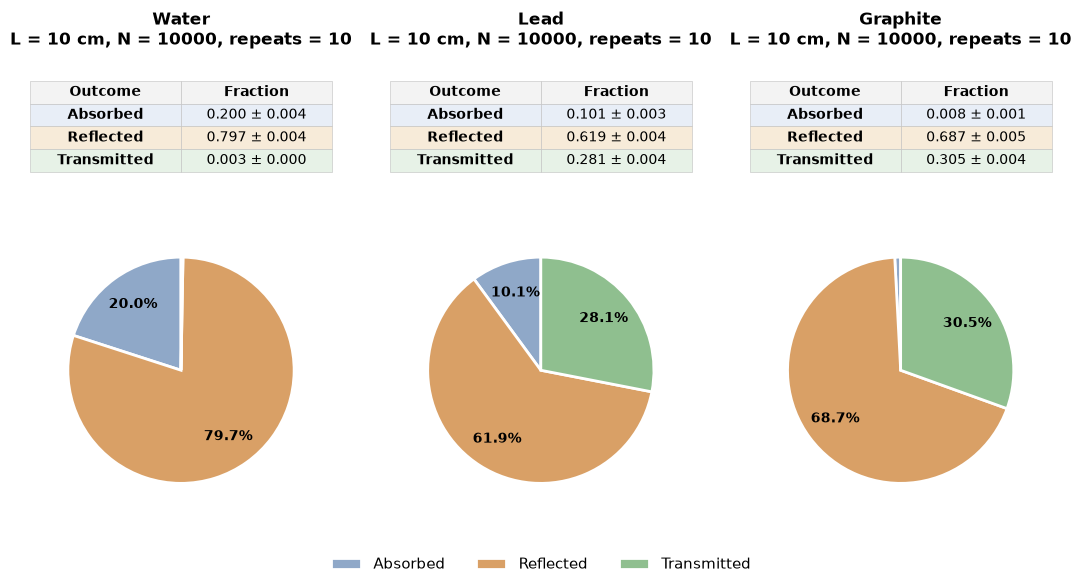

In [25]:
plt.rcParams["font.family"] = "DejaVu Sans"

materials = ["Water", "Lead", "Graphite"]
labels = ["Absorbed", "Reflected", "Transmitted"]
cols = ["#8FA8C8", "#D9A066", "#8FBF8F"]

fig, axes = plt.subplots(
    2, 3, figsize=(13, 6),
    gridspec_kw={"height_ratios": [1, 2]}
)

for i, name in enumerate(materials):

    row = simulate_slab_transport(
        name, slab_thickness, n_neutrons, n_repeats
    ).iloc[0]

    vals = [row["A mean"], row["R mean"], row["T mean"]]
    errs = [row["A std"], row["R std"], row["T std"]]

    # Top row: numerical summary table.
    ax = axes[0, i]
    ax.axis("off")
    ax.set_title(
        f"{name}\nL = {row['slab thickness / cm']:.0f} cm, "
        f"N = {int(row['N per repeat'])}, repeats = {int(row['number of repeats'])}",
        fontsize=12, fontweight="semibold", pad=8
    )

    table = ax.table(
        cellText=[[labels[k], f"{vals[k]:.3f} ± {errs[k]:.3f}"] for k in range(3)],
        colLabels=["Outcome", "Fraction"], cellLoc="center", loc="center")

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.05, 1.35)

    # Add colour to the table
    row_colours = {1: "#E8EEF7", 2: "#F7EBD9", 3: "#E7F2E7"}

    for (r, c), cell in table.get_celld().items():
        cell.set_linewidth(0.4)
        cell.set_edgecolor("0.75")
        if r == 0:
            cell.set_facecolor("#F3F3F3")
            cell.set_text_props(weight="semibold")
        else:
            cell.set_facecolor(row_colours[r])
            if c == 0:
                cell.set_text_props(weight="semibold")
    
    # Bottom row: outcome fractions as a pie chart.
    ax = axes[1, i]
    wedges, _, autotexts = ax.pie(
        vals,
        colors=cols,
        startangle=90,
        autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
        pctdistance=0.72,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )

    for t in autotexts:
        t.set_fontsize(10)
        t.set_weight("semibold")

    ax.set_aspect("equal")

fig.legend(wedges, labels, loc="lower center", ncol=3, frameon=False, fontsize=11)
plt.subplots_adjust(hspace=0.15, wspace=0.25, bottom=0.12)
plt.show()

For a fixed slab thickness of $L = 10\ \mathrm{cm}$, the three materials show clearly different shielding behaviour.

Water gives almost no transmission, with most neutrons being reflected and a smaller fraction absorbed. This occurs because water has a very large scattering cross-section, so neutrons undergo many direction-changing collisions before they can cross the slab. As a result, most histories are scattered back out of the incident side rather than transmitted through the material.

Lead and graphite both allow a much larger transmitted fraction than water. Lead has a noticeably larger absorption fraction than graphite, which is consistent with its larger macroscopic absorption cross-section. Graphite, on the other hand, has the smallest absorption fraction and the largest transmission fraction among the three materials, because absorption is weak and many neutrons survive long enough to escape from the far side.

Overall, these results show that neutron shielding is not determined by absorption alone. Strong scattering can strongly suppress transmission by redirecting neutrons backwards, as seen for water. Lead removes more neutrons through absorption, while graphite is comparatively transparent at this thickness.

---
# 7. Thickness Dependence and Attenuation Lengths
This section studies how neutron absorption, reflection and transmission change with slab thickness, and uses the transmission data to estimate the effective attenuation length for each material.

## 7.1 Absorption, reflection and transmission versus thickness
Using the tally method defined in the many-neutron simulation section, the slab simulation was repeated for a range of thickness values $L$. For each material and thickness, the final absorption, reflection and transmission fractions were recorded from repeated runs, and the resulting standard deviations were used as Monte Carlo error bars.

This scan tests how the shielding behaviour changes as the neutron path through the material becomes longer. As $L$ increases, transmission is expected to decrease because neutrons have more opportunities to scatter or be absorbed before reaching the far side of the slab. Absorption and reflection therefore become more important at larger thicknesses, with the exact trend depending on the macroscopic absorption and scattering cross-sections of each material.

In [26]:
thickness_values = np.array([1, 2, 3, 4, 5, 6, 7, 10, 15])  # Thickness range for the scan
N_scan = 10000       # Neutrons per repeated simulation
num_iter = 10        # Repeated runs used to estimate Monte Carlo scatter

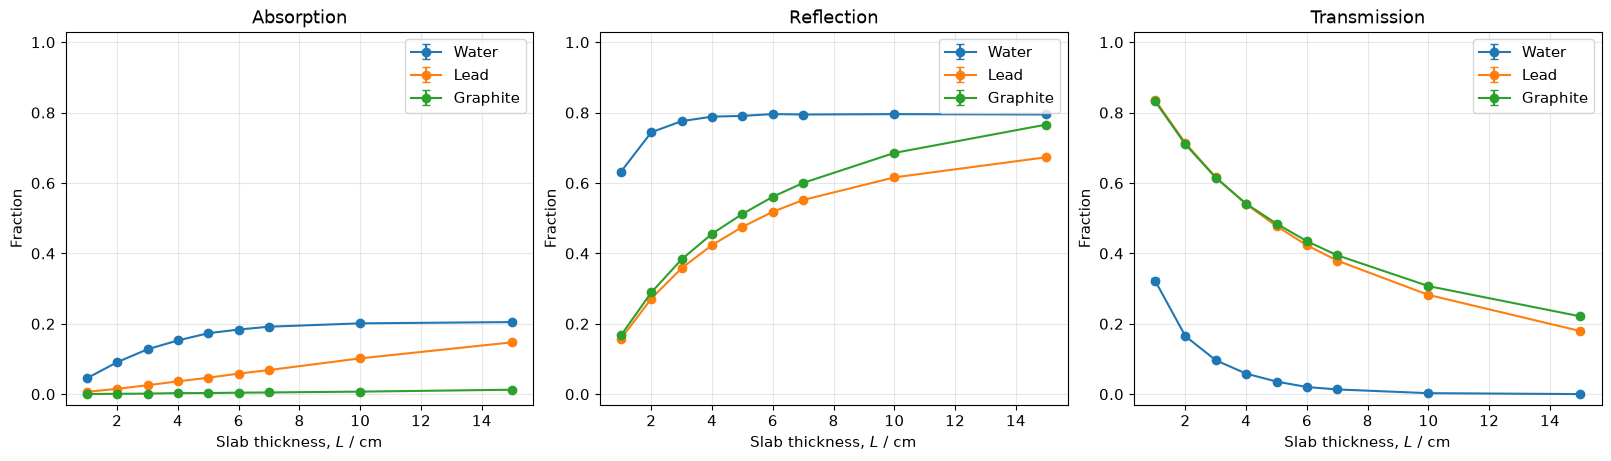

In [27]:
scan_rows = []

for material_name in materials:
    for L in thickness_values:
        scan_rows.append(simulate_slab_transport(
            material_name=material_name,
            slab_thickness=L,
            n_neutrons=N_scan,
            n_repeats=num_iter
        ))

thickness_scan_results = pd.concat(scan_rows, ignore_index=True).rename(
    columns={"slab thickness / cm": "L / cm"}
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

plot_info = [
    ("A mean", "A std", "Absorption"),
    ("R mean", "R std", "Reflection"),
    ("T mean", "T std", "Transmission")
]

for ax, (mean_col, std_col, title) in zip(axes, plot_info):
    for material_name in materials:
        data = thickness_scan_results[thickness_scan_results["material"] == material_name]
        ax.errorbar(data["L / cm"], data[mean_col], yerr=data[std_col],
                    marker="o", capsize=3, label=material_name)

    ax.set(xlabel="Slab thickness, $L$ / cm",
           ylabel="Fraction",
           title=title,
           ylim=(-0.03, 1.03))
    ax.legend()
    ax.grid(alpha=0.3)

plt.show()

As the slab thickness increases, the transmission fraction decreases for all three materials, because neutrons have a longer distance over which they can scatter or be absorbed before reaching the far side of the slab.

Water shows the strongest suppression of transmission. Even at small thickness, the transmitted fraction is much lower than for lead and graphite, and it rapidly falls to almost zero. The reflection fraction for water rises quickly and then saturates near $0.8$, while absorption increases only moderately. This suggests that water mainly acts as a strong scattering material: neutrons are repeatedly redirected and are more likely to leave through the incident side than pass through the slab.

Lead shows a steady increase in both absorption and reflection with thickness, while transmission decreases smoothly. Compared with graphite, lead has a larger absorption fraction at all thicknesses, which is consistent with its larger macroscopic absorption cross-section. Therefore, lead removes more neutrons by absorption as the slab becomes thicker.

Graphite has the smallest absorption fraction and maintains the highest transmission at large thickness. Its reflection fraction increases strongly with thickness, showing that scattering is still important, but because absorption is weak, more neutrons survive long enough to either transmit or reflect.

Overall, the thickness scan shows that increasing $L$ improves shielding by reducing transmission, but the mechanism differs between materials. Water mainly reduces transmission through strong backscattering, lead combines absorption and scattering, while graphite is the least absorbing and remains the most transparent material over this thickness range.

## 7.2 Determination of attenuation length

The thickness scan can also be used to estimate an effective attenuation length for each material. If the transmitted fraction decreases approximately exponentially with slab thickness, then

$$
T(L) \approx T_0 e^{-L/\lambda_{\mathrm{att}}},
$$

where $T_0$ is a fitted constant and $\lambda_{\mathrm{att}}$ is the attenuation length. Taking the logarithm gives a linear relation,

$$
\ln(T) = \ln(T_0) - \frac{L}{\lambda_{\mathrm{att}}}.
$$

Therefore, fitting $\ln(T)$ against $L$ gives a straight-line gradient

$$
m = -\frac{1}{\lambda_{\mathrm{att}}},
$$

so that

$$
\lambda_{\mathrm{att}} = -\frac{1}{m}.
$$

Only non-zero transmission values are included in the fit, because $\ln(0)$ is undefined. The uncertainty in the logarithm is obtained by propagating the uncertainty in the transmission fraction,

$$
\sigma_{\ln T} = \frac{\sigma_T}{T}.
$$

A weighted linear fit is then performed using $1/\sigma_{\ln T}$ as the fitting weight. The fitted attenuation length and its uncertainty are extracted from the fitted gradient and its covariance. The reduced chi-squared value is also calculated to check how well the exponential attenuation model describes the simulated transmission data.

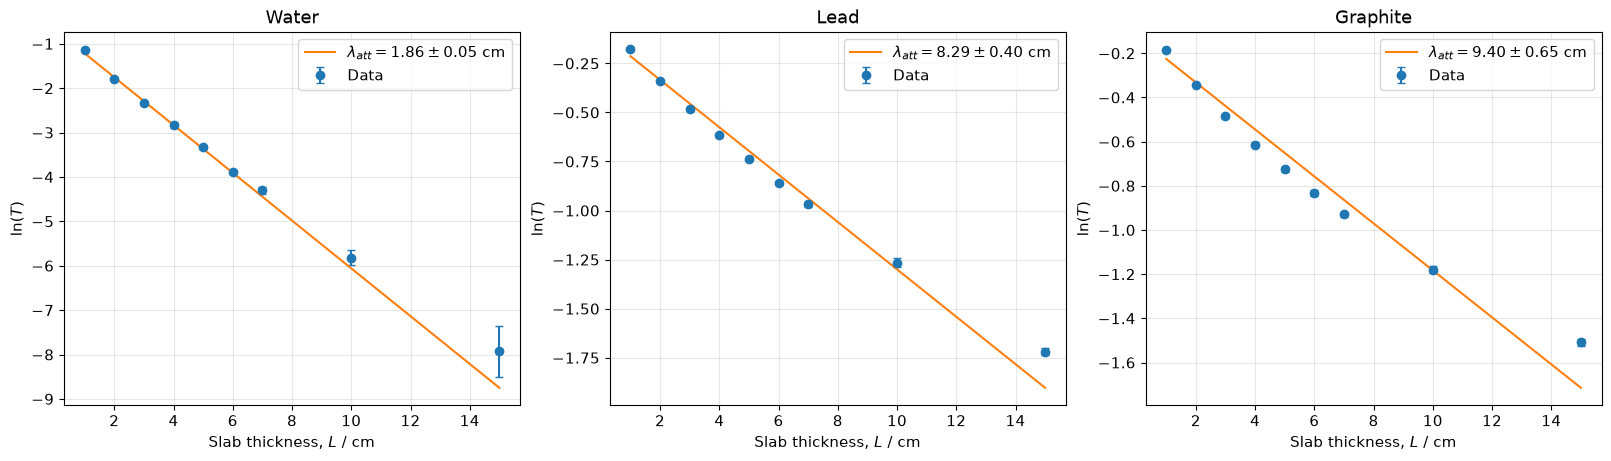

,material,lambda_att / cm,lambda uncertainty / cm,reduced chi2
0,Water,1.858517,0.054748,5.659619
1,Lead,8.285208,0.403898,39.336893
2,Graphite,9.404501,0.646256,65.128967


In [28]:
fit_rows = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for ax, material_name in zip(axes, materials):

    data = thickness_scan_results.query("material == @material_name")
    L, T, dT = (data["L / cm"].to_numpy(),
                data["T mean"].to_numpy(),
                data["T std"].to_numpy())

    valid = (T > 0) & (dT > 0)
    L, T, dT = L[valid], T[valid], dT[valid]
    error = dT / T

    coefficient, covariance = np.polyfit(L, np.log(T), 1, cov=True, w=1/error)
    slope, intercept = coefficient

    lambda_att = -1 / slope
    lambda_unc = np.sqrt(covariance[0, 0]) / slope**2
    L_line = np.linspace(L.min(), L.max(), 300)

    ax.errorbar(L, np.log(T), yerr=error, fmt="o", capsize=3, label="Data")
    ax.plot(L_line, intercept + slope * L_line,
            label=rf"$\lambda_{{att}}={lambda_att:.2f}\pm{lambda_unc:.2f}$ cm")
    ax.set(xlabel="Slab thickness, $L$ / cm",
           ylabel=r"$\ln(T)$",
           title=material_name)
    ax.legend()
    ax.grid(alpha=0.3)

    reduced_chi2 = np.sum(((np.log(T) - (slope * L + intercept)) / error)**2) / (len(L) - 2)

    fit_rows.append({
        "material": material_name,
        "lambda_att / cm": lambda_att,
        "lambda uncertainty / cm": lambda_unc,
        "reduced chi2": reduced_chi2
    })

plt.show()

attenuation_summary = pd.DataFrame(fit_rows)
attenuation_summary

The fitted attenuation trends confirm that transmission decreases as the slab becomes thicker, but the rate of decrease is strongly material-dependent.

Water shows the strongest attenuation, with transmission dropping very rapidly as thickness increases. This agrees with the earlier result that water is highly effective at suppressing transmitted neutrons, mainly because strong scattering redirects many histories back out of the incident side.

Lead and graphite show a slower decrease in transmission over the same thickness range. Their attenuation behaviour is broadly similar, although graphite remains slightly more transparent in the simulated range, while lead removes more neutrons through absorption.

The fits are useful for comparing the materials, but they should be interpreted as effective attenuation trends rather than exact exponential laws. The large reduced chi-squared values indicate that a single exponential is only an approximate effective description of the transport data, rather than a statistically perfect model. This is expected because scattering and reflection make the transmission curve more complex than absorption-only attenuation. Once scattering is included, neutron transport is no longer purely absorption-driven: particles can be redirected, reflected, or transmitted after many collisions. This makes the transmission curve more complex than the absorption-only case.

---
# 8. Extension: Woodcock Method for Two-Layer Slabs
This section extends the single-material transport model to a heterogeneous two-layer slab using the Woodcock method. The validation step uses all three materials by comparing two identical adjacent slabs with the corresponding single slab of twice the thickness. After validation, the material comparison focuses mainly on lead and graphite as first-layer materials, while water is included only as a second-layer material. This allows the lead--graphite ordering effect to be compared while also showing how strongly the transmitted fraction changes when a highly scattering water layer is placed after the first shielding layer.

## 8.1 Woodcock tracking for two adjacent slabs

The Woodcock method was used to simulate neutron transport through two adjacent slabs, each with thickness $10\ \mathrm{cm}$. Instead of stopping the neutron exactly at the material boundary, one common step-length distribution was used across both materials. This was done by choosing the majorant cross-section

$$
\Sigma_M=\max(\Sigma_{T,1},\Sigma_{T,2}),
$$

so that each proposed Woodcock step had mean free path

$$
\lambda_M=\frac{1}{\Sigma_M}.
$$

After each proposed step, the neutron position was used to identify whether it was in the left or right slab. A candidate collision was accepted as a real collision with probability

$$
P_{\mathrm{real}}(x)=\frac{\Sigma_T(x)}{\Sigma_M}.
$$

If the collision was rejected, it was treated as a fictitious collision, so the neutron continued in the same direction without absorption or scattering. If the collision was real, the local absorption probability was applied:

$$
P_a(x)=\frac{\Sigma_a(x)}{\Sigma_T(x)}.
$$

Otherwise, the neutron was scattered isotropically using the direction sampler from Section 3.1. The simulation was repeated for ordered material pairs, and the mean absorption, reflection and transmission fractions were recorded with their repeat-to-repeat standard deviations.

In [29]:
# Woodcock two-slab simulation parameters
woodcock_slab_thickness = 10.0
woodcock_n_neutrons = 10000
woodcock_n_repeats = 10

In [30]:
def take_next_woodcock_step(x, theta, phi, fictitious, lambda_large):

   # First generate new isotropic directions for all active particles.
    theta_new = np.arccos(sample_isotropic_mu(len(x)))  # Section 3.1.
    phi_new = np.random.uniform(0.0, 2.0 * np.pi, len(x))

    theta_new[np.argwhere(fictitious == True)] = theta[np.argwhere(fictitious == True)]
    phi_new[np.argwhere(fictitious == True)] = phi[np.argwhere(fictitious == True)]

    # Move all active particles to the next Woodcock collision site.
    x += sample_exponential_steps(lambda_large, len(x)) * np.sin(theta_new) * np.cos(phi_new)

    return x, theta_new, phi_new

In [31]:
def simulate_woodcock_two_slabs(material_1, material_2, slab_thickness, n_neutrons, n_repeats):

    # Section 4: material data
    Sa_left, _, ST_left = get_fast_material_data(material_1)
    Sa_right, _, ST_right = get_fast_material_data(material_2)
    total_thickness = 2.0 * slab_thickness

    # Identify the slab with the larger total cross section.
    if ST_left >= ST_right:
        Sa_large, ST_large = Sa_left, ST_left
        Sa_small, ST_small = Sa_right, ST_right
        large_min_x, large_max_x = 0.0, slab_thickness
        small_min_x, small_max_x = slab_thickness, total_thickness
    else:
        Sa_large, ST_large = Sa_right, ST_right
        Sa_small, ST_small = Sa_left, ST_left
        large_min_x, large_max_x = slab_thickness, total_thickness
        small_min_x, small_max_x = 0.0, slab_thickness

    lambda_large = 1.0 / ST_large
    P_abs_large = Sa_large / ST_large
    P_abs_small = Sa_small / ST_small
    P_real_small = ST_small / ST_large

    num_absorbed = np.zeros(n_repeats)
    num_reflected = np.zeros(n_repeats)
    num_transmitted = np.zeros(n_repeats)

    for j in range(n_repeats):

        # First step: normal incidence along +x.
        x = sample_exponential_steps(lambda_large, n_neutrons)  # Section 2.1.
        theta = np.full(n_neutrons, np.pi / 2)
        phi = np.zeros(n_neutrons)

        while len(x) > 0:

            num_reflected[j] += np.count_nonzero(x < 0)
            num_transmitted[j] += np.count_nonzero(x > total_thickness)

            escaped_particles = np.argwhere((x < 0) | (x > total_thickness)).flatten()
            x = np.delete(x, escaped_particles)
            theta = np.delete(theta, escaped_particles)
            phi = np.delete(phi, escaped_particles)

            in_large_slab = (x > large_min_x) & (x < large_max_x)
            in_small_slab = (x > small_min_x) & (x < small_max_x)

            # Fictitious collisions only occur in the smaller-cross-section slab.
            v = np.random.uniform(size=len(x))
            fictitious = np.full(len(x), False)
            fictitious[np.argwhere(in_small_slab & (v > P_real_small)).flatten()] = True

            # Absorption test in each slab.
            u = np.random.uniform(size=len(x))

            absorbed_large = np.argwhere(
                in_large_slab & (u < P_abs_large)
            ).flatten()

            absorbed_small = np.argwhere(
                in_small_slab & (u < P_abs_small) & (fictitious == False)
            ).flatten()

            absorbed_particles = np.append(absorbed_large, absorbed_small).astype(int)
            num_absorbed[j] += len(absorbed_particles)
            
            # Remove absorbed particles from the active particle list.
            x = np.delete(x, absorbed_particles)
            theta = np.delete(theta, absorbed_particles)
            phi = np.delete(phi, absorbed_particles)
            fictitious = np.delete(fictitious, absorbed_particles)

            # Fictitious particles keep their old direction inside this function.
            x, theta, phi = take_next_woodcock_step(x, theta, phi, fictitious, lambda_large)
            
    rates = np.column_stack([num_absorbed, num_reflected, num_transmitted]) / n_neutrons

    return pd.DataFrame({
        "left slab": [material_1],
        "right slab": [material_2],
        "A mean": [rates[:, 0].mean()],
        "A std": [rates[:, 0].std(ddof=1)],
        "R mean": [rates[:, 1].mean()],
        "R std": [rates[:, 1].std(ddof=1)],
        "T mean": [rates[:, 2].mean()],
        "T std": [rates[:, 2].std(ddof=1)],
        "mean A + R + T": [rates.sum(axis=1).mean()]
    })

## 8.2 Woodcock two-slab validation and material comparison

The Woodcock method was then tested for two adjacent slabs. In this method, step lengths are sampled using the majorant total cross-section, so particles can be transported across material boundaries without explicitly stopping and restarting at the interface. When a proposed interaction is fictitious, the neutron keeps its previous direction and continues moving; otherwise, the usual absorption-or-scattering decision is applied at the end of the step.

As a validation check, each material was first simulated as two identical $5\ \mathrm{cm}$ slabs. This should reproduce the result of a single $10\ \mathrm{cm}$ slab of the same material, because there is no physical material boundary in this special case. The Woodcock and single-slab results were compared using the absorption, reflection and transmission fractions, with their uncertainties estimated from repeated runs.

After this check, the method was applied to selected two-layer systems. Lead and graphite were used as possible first-layer materials, while lead, water and graphite were tested as second-layer materials. This keeps the comparison focused on lead--graphite ordering effects while also showing how strongly the result changes when water is placed after the first shielding layer. The table reports the mean absorption, reflection and transmission fractions for each ordering, while the heatmap highlights how the transmitted fraction depends on the choice of the right-hand layer.

The mean-difference diagnostic combines standard errors: sqrt(s_W²/n_W + s_S²/n_S). The two-standard-error threshold is descriptive, not an exact confidence test or proof of unbiased transport. Elsewhere, error bars labelled std show repeat-to-repeat sample standard deviations, not uncertainty of the mean.


In [32]:
# Validate Woodcock tracking: two identical 5 cm slabs should match one 10 cm slab

validation_materials = ["Water", "Lead", "Graphite"]
validation_slab_thickness = 5.0
validation_total_thickness = 2 * validation_slab_thickness

woodcock_same = pd.concat([
    simulate_woodcock_two_slabs(mat, mat, validation_slab_thickness,
                                woodcock_n_neutrons, woodcock_n_repeats)
    for mat in validation_materials
], ignore_index=True)

# Section 6 single-slab function
single_10 = pd.concat([
    simulate_slab_transport(mat, validation_total_thickness,
                            woodcock_n_neutrons, woodcock_n_repeats)
    for mat in validation_materials
], ignore_index=True)

validation_rows = []

for mat in validation_materials:
    w = woodcock_same[woodcock_same["left slab"] == mat].iloc[0]
    s = single_10[single_10["material"] == mat].iloc[0]

    row = {"material": mat}

    for q in ["A", "R", "T"]:
        diff = w[f"{q} mean"] - s[f"{q} mean"]
        sigma = np.sqrt((w[f"{q} std"]**2 + s[f"{q} std"]**2) / woodcock_n_repeats)

        row[f"Woodcock {q}"] = f"{w[f'{q} mean']:.3f} ± {w[f'{q} std']:.3f}"
        row[f"Single 10 cm {q}"] = f"{s[f'{q} mean']:.3f} ± {s[f'{q} std']:.3f}"
        row[f"Δ{q}"] = f"{diff:.3f}"
        row[f"within 2 combined SE {q}"] = abs(diff) <= 2 * sigma

    validation_rows.append(row)

validation_df = pd.DataFrame(validation_rows)
validation_df

,material,Woodcock A,Single 10 cm A,ΔA,within 2 combined SE A,Woodcock R,Single 10 cm R,ΔR,within 2 combined SE R,Woodcock T,Single 10 cm T,ΔT,within 2 combined SE T
0,Water,0.202 ± 0.004,0.199 ± 0.002,0.003,True,0.795 ± 0.004,0.798 ± 0.002,-0.003,True,0.003 ± 0.001,0.003 ± 0.001,0.000,True
1,Lead,0.100 ± 0.003,0.100 ± 0.003,-0.000,True,0.618 ± 0.006,0.619 ± 0.004,-0.001,True,0.282 ± 0.006,0.281 ± 0.003,0.001,True
2,Graphite,0.008 ± 0.001,0.008 ± 0.001,-0.000,True,0.685 ± 0.003,0.685 ± 0.004,-0.000,True,0.307 ± 0.003,0.307 ± 0.004,0.000,True


In [33]:
# Woodcock two-slab results: Water only allowed as the right slab

woodcock_left_materials = ["Lead", "Graphite"]
woodcock_right_materials = ["Lead", "Water", "Graphite"]

woodcock_pairs_ordered = [
    (left, right)
    for left in woodcock_left_materials
    for right in woodcock_right_materials
]

woodcock_summary_ordered = pd.concat([
    simulate_woodcock_two_slabs(mat1, mat2, woodcock_slab_thickness,
                                woodcock_n_neutrons, woodcock_n_repeats)
    for mat1, mat2 in woodcock_pairs_ordered
], ignore_index=True)

T_mean = woodcock_summary_ordered.pivot(
    index="left slab", columns="right slab", values="T mean"
).loc[woodcock_left_materials, woodcock_right_materials]

T_std = woodcock_summary_ordered.pivot(
    index="left slab", columns="right slab", values="T std"
).loc[woodcock_left_materials, woodcock_right_materials]

print("Woodcock two-slab simulations completed.")

Woodcock two-slab simulations completed.


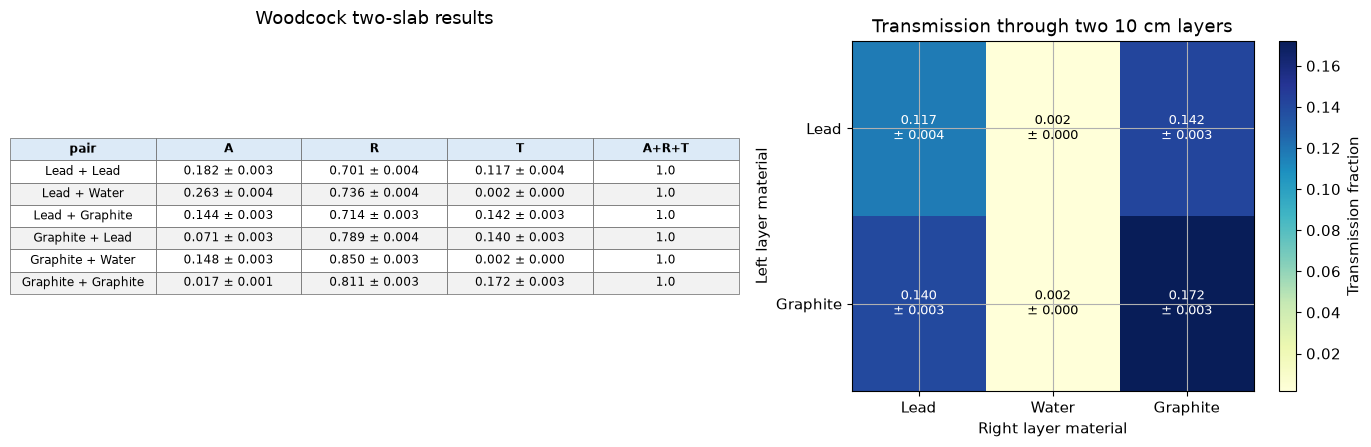

In [34]:
table_df = pd.DataFrame({
    "pair": woodcock_summary_ordered["left slab"] + " + " + woodcock_summary_ordered["right slab"],
    "A": [f"{m:.3f} ± {s:.3f}" for m, s in zip(woodcock_summary_ordered["A mean"], woodcock_summary_ordered["A std"])],
    "R": [f"{m:.3f} ± {s:.3f}" for m, s in zip(woodcock_summary_ordered["R mean"], woodcock_summary_ordered["R std"])],
    "T": [f"{m:.3f} ± {s:.3f}" for m, s in zip(woodcock_summary_ordered["T mean"], woodcock_summary_ordered["T std"])],
    "A+R+T": woodcock_summary_ordered["mean A + R + T"].round(3)
})

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 4.6),
    gridspec_kw={"width_ratios": [1.45, 1]}
)

ax1.axis("off")
table = ax1.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#666666")
    cell.set_linewidth(0.5)

    if row == 0:
        cell.set_facecolor("#DCEAF7")
        cell.set_text_props(weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F2F2F2")
    else:
        cell.set_facecolor("white")

ax1.set_title("Woodcock two-slab results", pad=12)

values = T_mean.values
im = ax2.imshow(values, cmap="YlGnBu", aspect="auto")

ax2.set(
    xticks=np.arange(len(woodcock_right_materials)),
    yticks=np.arange(len(woodcock_left_materials)),
    xticklabels=woodcock_right_materials,
    yticklabels=woodcock_left_materials,
    xlabel="Right layer material",
    ylabel="Left layer material",
    title=r"Transmission through two $10\ \mathrm{cm}$ layers"
)

threshold = 0.5 * (values.min() + values.max())

for i in range(len(woodcock_left_materials)):
    for j in range(len(woodcock_right_materials)):
        colour = "white" if values[i, j] > threshold else "black"

        ax2.text(
            j, i,
            f"{T_mean.iloc[i, j]:.3f}\n± {T_std.iloc[i, j]:.3f}",
            ha="center",
            va="center",
            color=colour,
            fontsize=9
        )

fig.colorbar(im, ax=ax2, label="Transmission fraction")
plt.tight_layout()
plt.show()

The validation test provides a consistency check that the Woodcock implementation behaves consistently. For each material, two identical $5\ \mathrm{cm}$ slabs reproduce the corresponding single $10\ \mathrm{cm}$ slab within uncertainty. This is an important check because, when both layers are made from the same material, the artificial interface should not change the physical transport result.

The two-layer results show that the choice of the second layer has a strong effect on transmission. When water is placed as the right-hand layer, the transmitted fraction becomes almost zero for both lead--water and graphite--water. This is consistent with the strong scattering behaviour of water observed in the single-slab simulations: neutrons entering the water layer are very unlikely to pass through it and are mostly redirected or removed before reaching the far side.

Among the non-water cases, graphite--graphite gives the largest transmission, while lead--lead gives the smallest. This is physically reasonable because lead has a larger macroscopic absorption cross-section than graphite, so it removes more neutrons from the beam. Graphite is less absorbing, so more neutron histories survive long enough to transmit through the shield.

The mixed lead--graphite and graphite--lead systems give similar transmission fractions within uncertainty, suggesting that the total material composition is more important than the ordering for these two $10\ \mathrm{cm}$ layers. However, the absorption and reflection fractions still change with ordering: placing graphite first gives a larger reflected fraction and a smaller absorbed fraction, because graphite is more scattering-dominated and can redirect neutrons backwards before they reach the second layer.

Overall, the Woodcock method successfully handles material boundaries with no discrepancy resolved by this diagnostic. The results also show that layered shielding behaviour cannot be judged from transmission alone: absorption and reflection must also be compared to understand how the shield redistributes neutron histories.

## 8.3 Exploratory extension: machine-learning surrogate model for shielding design

As an additional extension, I investigated whether the Monte Carlo transport simulation could be used to generate training data for a simple machine-learning surrogate model. This goes beyond directly simulating a small number of shielding cases: instead, the simulation results are treated as synthetic experimental data, similar to transmission counts measured by a detector in a real neutron shielding experiment.

In practice, measuring every possible material ordering and thickness combination would be time-consuming. A surrogate model can learn the relationship between material properties, layer thickness and the transmitted fraction, allowing new shield designs to be screened quickly before performing more expensive experiments or high-statistics simulations.

Here, Woodcock simulations were run for lead--graphite two-layer shields with different layer thicknesses. The input features were the macroscopic cross-sections of each layer and the layer thickness, while the target output was the simulated transmission fraction.

This is an exploratory surrogate study based on synthetic simulation targets, not measured experimental data. Total cross section is the sum of absorption and scattering cross sections; the input features are therefore redundant. Feature importance should not be interpreted as independent physical causation.


In [35]:
# Generate a small Woodcock dataset for machine-learning regression
ml_materials = ["Lead", "Graphite"]
ml_thickness_values = np.array([2, 5, 8, 10, 12, 15])
ml_n_neutrons = 3000
ml_n_repeats = 3

In [36]:
ml_rows = []

for thickness in ml_thickness_values:
    for left in ml_materials:
        for right in ml_materials:

            result = simulate_woodcock_two_slabs(
                left, right, thickness,
                ml_n_neutrons, ml_n_repeats
            ).iloc[0]

            Sa_l, Ss_l, ST_l = get_fast_material_data(left)
            Sa_r, Ss_r, ST_r = get_fast_material_data(right)

            ml_rows.append({
                "left slab": left,
                "right slab": right,
                "layer thickness": thickness,
                "Sigma_a_left": Sa_l,
                "Sigma_s_left": Ss_l,
                "Sigma_T_left": ST_l,
                "Sigma_a_right": Sa_r,
                "Sigma_s_right": Ss_r,
                "Sigma_T_right": ST_r,
                "T mean": result["T mean"],
                "T std": result["T std"]
            })

ml_data = pd.DataFrame(ml_rows)

Mean absolute error: 0.0162
R² score: 0.981


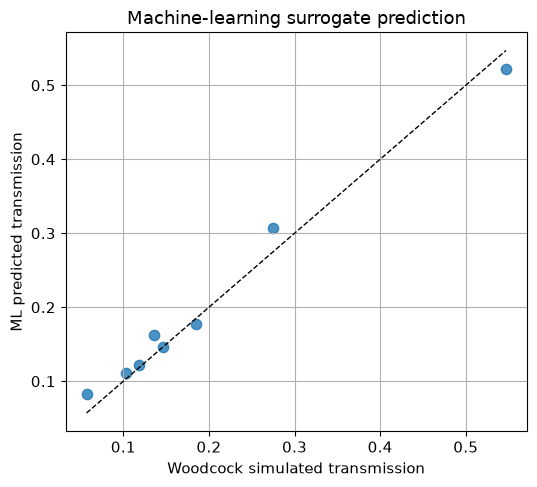

In [37]:
# Train a machine-learning surrogate model for the transmitted fraction
features = [
    "layer thickness",
    "Sigma_a_left", "Sigma_s_left", "Sigma_T_left",
    "Sigma_a_right", "Sigma_s_right", "Sigma_T_right"
]

X = ml_data[features]
y = ml_data["T mean"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae:.4f}")
print(f"R² score: {r2:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5))

ax.scatter(y_test, y_pred, s=55, alpha=0.8)

limit_min = min(y_test.min(), y_pred.min())
limit_max = max(y_test.max(), y_pred.max())

ax.plot([limit_min, limit_max], [limit_min, limit_max], "k--", lw=1)

ax.set(
    xlabel="Woodcock simulated transmission",
    ylabel="ML predicted transmission",
    title="Machine-learning surrogate prediction"
)

plt.tight_layout()
plt.show()

The random split evaluates held-out configurations from a small grid of 24 cases. It does not establish prediction accuracy at unseen thicknesses or materials. The separate leave-one-thickness-out analysis in `../results/thickness_summary.csv` compares the unchanged random forest with a training-mean baseline and same-material-pair interpolation. In that diagnostic, simple interpolation performs better on interior held-out thicknesses. These are exploratory cross-validation results, not an independent final test set. No model speedup benchmark is provided.


# 9. Conclusion
This project developed and validated a Monte Carlo model for thermal neutron transport through shielding materials. The simulation began with checks of the random-number generator, exponential path-length sampling and isotropic direction generation, so that the later neutron histories were built from tested sampling components rather than assumed black-box functions.

The single-slab transport model showed that water, lead and graphite have clearly different shielding behaviour. Water strongly suppresses transmission mainly through repeated scattering and back-reflection. Lead gives a larger absorption contribution, while graphite is the least absorbing and remains comparatively more transparent over the simulated thickness range. This demonstrates that neutron shielding cannot be judged from absorption alone: scattering and reflection are equally important in determining how many neutrons reach the far side of the slab.

The thickness scan confirmed that transmission decreases as the slab becomes thicker for all three materials. Effective attenuation lengths were extracted from the transmission data, giving a compact way to compare the materials. However, these attenuation lengths should be interpreted as effective transport parameters rather than exact absorption-only mean free paths, because scattered neutrons can change direction many times before being absorbed, reflected or transmitted.

The Woodcock extension successfully generalised the simulation to two adjacent materials. The validation test showed that two identical adjacent slabs reproduce the corresponding single-slab result, confirming that the artificial interface does not introduce a visible bias. The comparisons then demonstrated how the same Woodcock framework can be used to study layered shielding systems without explicitly stopping neutron histories at the material boundary.

Finally, a machine-learning surrogate model was introduced as an additional extension. Monte Carlo results were treated as synthetic experimental data, and a regression model was trained to predict transmission from material cross-sections and layer thickness. This provides a proof of concept for a realistic workflow in which experimental or high-statistics simulation data could be used to rapidly screen candidate shielding designs before performing more expensive measurements.

Overall, the notebook satisfies the main project goals: it validates the random sampling methods, simulates absorption, reflection and transmission through finite slabs, studies thickness dependence, estimates effective attenuation lengths, and extends the calculation to heterogeneous two-layer shielding. The results show that Monte Carlo particle transport is a powerful method because it can model both probabilistic interactions and complex neutron histories that are difficult to capture with a simple analytic attenuation law.

# Appendix: Runtime

Wall-clock time depends on the computer, software versions and notebook rendering. It is not a surrogate-versus-simulation benchmark.


In [38]:
notebook_runtime = time.perf_counter() - notebook_start_time
print(f"Total notebook runtime: {notebook_runtime:.2f} s")


Total notebook runtime: 21.88 s


In [39]:
from pathlib import Path
output_dir = Path.cwd().parent / "results"
output_dir.mkdir(exist_ok=True)
for name in ["ml_data", "validation_df", "woodcock_same", "single_10",
             "thickness_scan_results", "attenuation_summary", "woodcock_summary_ordered"]:
    globals()[name].to_csv(output_dir / f"{name}.csv", index=False)
for name in ["thickness_scan_results", "woodcock_same", "single_10", "woodcock_summary_ordered"]:
    frame = globals()[name]
    values = frame[["A mean", "R mean", "T mean"]].to_numpy()
    assert np.all((values >= 0) & (values <= 1)), name
    assert np.allclose(values.sum(axis=1), 1.0), name
assert abs(np.mean(steps_test) - lambda_test) < 5 * lambda_test / np.sqrt(N_test)
print("Validation passed: probability bounds, tally conservation, exponential sample mean.")


Validation passed: probability bounds, tally conservation, exponential sample mean.
